# Entrega 2 · Análisis exploratorio del proyecto integrador

**Grupo:** 5K10-07  
**Integrantes:** Berducci Nicolás · Genaulaz Martin · Yanardi Tomás · Yanardi Juan Cruz · Gallardo Federico · León Mario  
**Pregunta de investigación:** En un enfrentamiento entre dos equipos de Counter-Strike 2, ¿quién será el vencedor?

**Unidad de análisis:** un partido competitivo finalizado.  
**Clave primaria:** `match_id`.  
**Variable objetivo:** `target_team_a_won` (1 si gana A, 0 si gana B).  
**Momento de predicción:** inmediatamente antes del inicio del partido.


## 1. Qué cambió desde la Entrega 1

La devolución de la Entrega 1 acordó dos cambios: reemplazar PandaScore por scraping de Bo3.gg (encontramos algunos endpoints que nos ahorran el hacer un scrapping puro) y enriquecer Silver con información agregada sobre la calidad de los equipos. PandaScore aportaba principalmente datos descriptivos del partido y su ganador; Bo3.gg permite conservar en Bronze los detalles, mapas, rondas y estadísticas y producir un Silver con una fila por partido.

La pregunta de investigación no cambió. En esta entrega, además de perfilar Silver, construimos variables históricas Gold usando únicamente partidos anteriores. Esta separación es esencial: las columnas `post_*` describen el resultado observado y no pueden entrar directamente al modelo que predice ese mismo partido.


## 2. Preparación y carga reproducible

El dataset se monta desde Google Drive. Antes de ejecutar, editar únicamente `RUTA_CSV_DRIVE` para que apunte a `matches_latest.csv`. El notebook también reconoce automáticamente la ruta local del proyecto cuando se ejecuta fuera de Colab.


In [ ]:
from pathlib import Path
import heapq
import warnings

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
sns.set_theme(style="whitegrid", context="notebook")

ARCHIVO = "matches_latest.csv"

# 1. Verificamos que el archivo esté en el entorno
if not os.path.exists(ARCHIVO):
    raise FileNotFoundError(f"No se encuentra '{ARCHIVO}'. Súbelo al panel de Archivos de Colab.")

# 2. Lectura directa del CSV (Saltamos el control SHA)
df = pd.read_csv(ARCHIVO, low_memory=False)
df["start_at_utc"] = pd.to_datetime(df["start_at_utc"], utc=True, errors="coerce")

for columna in ["start_at_utc", "end_at_utc", "rank_extracted_at_utc"]:
    if columna in df.columns:
        df[columna] = pd.to_datetime(df[columna], utc=True, errors="coerce")

print(f"Archivo: {ARCHIVO}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
display(df.head(3))


Archivo: matches_latest.csv
Dimensiones: 44,484 filas × 120 columnas


,match_id,match_slug,start_at_utc,end_at_utc,duration_seconds,bo_type,tier,game_version,tournament_id,tournament_name,stage_id,stage_name,team_a_id,team_a_name,team_a_country_code,team_b_id,team_b_name,team_b_country_code,team_a_rank_at_extraction,team_b_rank_at_extraction,rank_extracted_at_utc,winner_team_id,loser_team_id,target_team_a_won,post_team_a_maps_won,post_team_b_maps_won,post_maps_played,post_map_1_game_id,post_map_1_name,post_map_1_winner_team_id,post_map_1_team_a_score,post_map_1_team_b_score,post_map_1_rounds_count,post_map_1_overtime,post_map_2_game_id,post_map_2_name,post_map_2_winner_team_id,post_map_2_team_a_score,post_map_2_team_b_score,post_map_2_rounds_count,post_map_2_overtime,post_map_3_game_id,post_map_3_name,post_map_3_winner_team_id,post_map_3_team_a_score,post_map_3_team_b_score,post_map_3_rounds_count,post_map_3_overtime,post_map_4_game_id,post_map_4_name,post_map_4_winner_team_id,post_map_4_team_a_score,post_map_4_team_b_score,post_map_4_rounds_count,post_map_4_overtime,post_map_5_game_id,post_map_5_name,post_map_5_winner_team_id,post_map_5_team_a_score,post_map_5_team_b_score,post_map_5_rounds_count,post_map_5_overtime,post_team_a_rounds_won,post_team_b_rounds_won,post_round_difference_a,post_total_rounds,post_team_a_ct_rounds_won,post_team_a_t_rounds_won,post_team_b_ct_rounds_won,post_team_b_t_rounds_won,post_team_a_overtime_rounds_won,post_team_b_overtime_rounds_won,post_team_a_kills,post_team_a_deaths,post_team_a_assists,post_team_a_headshots,post_team_a_first_kills,post_team_a_first_deaths,post_team_a_trade_kills,post_team_a_trade_deaths,post_team_a_damage,post_team_a_got_damage,post_team_a_hits,post_team_a_shots,post_team_a_flash_assists,post_team_a_grenades_damage,post_team_a_clutches,post_team_a_money_spent,post_team_a_equipment_value,post_team_a_player_rating_mean,post_team_a_adr_mean,post_team_a_kast_mean,post_team_a_players_stats_count,post_team_b_kills,post_team_b_deaths,post_team_b_assists,post_team_b_headshots,post_team_b_first_kills,post_team_b_first_deaths,post_team_b_trade_kills,post_team_b_trade_deaths,post_team_b_damage,post_team_b_got_damage,post_team_b_hits,post_team_b_shots,post_team_b_flash_assists,post_team_b_grenades_damage,post_team_b_clutches,post_team_b_money_spent,post_team_b_equipment_value,post_team_b_player_rating_mean,post_team_b_adr_mean,post_team_b_kast_mean,post_team_b_players_stats_count,team_a_lineup_profile_ids,team_b_lineup_profile_ids,team_a_lineup_size,team_b_lineup_size,parsed_status,data_completeness
0,36178,take-flyte-vs-mythic-27-09-2023,2023-09-27 00:00:00+00:00,2023-09-27 03:11:33.793000+00:00,11493.0,3,b,1.0,1581,ESL Challenger League Season 46: North America,3094.0,ESL Challenger League Season 46: North America...,606,Mythic,US,2882,Take Flyte,US,373.0,NaN,2026-09-21 22:39:55.232880+00:00,2882,606,0,1,2,3,69916.0,de_anubis,606.0,16.0,8.0,24.0,False,69915.0,de_ancient,2882.0,11.0,16.0,27.0,False,69914.0,de_inferno,2882.0,12.0,16.0,28.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,40.0,-1.0,79.0,23.0,16.0,18.0,22.0,0.0,0.0,262.0,286.0,53.0,115.0,38.0,38.0,55.0,57.0,29412.0,31499.0,867.0,4817.0,7.0,1601.0,5.0,1127250.0,1597500.0,5.897680,74.711155,0.708818,5.0,285.0,264.0,68.0,147.0,39.0,39.0,56.0,56.0,30940.0,30146.0,860.0,6181.0,26.0,2533.0,7.0,1115650.0,1668200.0,6.269224,78.110802,0.717372,5.0,267;372;954;2419;3690,1242;2367;3749;10562;11960,5.0,5.0,done,complete
1,36447,evil-geniuses-vs-kari-27-09-2023,2023-09-27 00:00:00+00:00,NaT,10879.0,3,b,1.0,1581,ESL Challenger League Season 46: North America,3094.0,ESL Challenger League Season 46: North America...,551,Evil Geniuses,US,3729,Kari,US,NaN,NaN,2026-09-21 22:39:59.222912+00:00,551,3729,1,2,1,3,70356.0,de_nuke,551.0,16.0,10.0,26.0,False,70355.0,de_ancient,3729.0,14.0,16.0,30.0,False,70354.0,de_mirage,551.0,16.0,3.0,19.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,29.0,17.0,75.0,30.0,16.0,14.0,15.0,0.0,0.0,280.0,216.0,64.0,133.0,46.0,29.0,44.0,46.0,30128

## 3. Contrato analítico

Una fila representa un partido competitivo finalizado entre dos equipos. Para evitar que el orden de la fuente introduzca sesgo, el pipeline define A como el equipo de menor `team_id` y B como el otro. La variable `target_team_a_won` indica si ganó A.

Las columnas `post_*`, `winner_team_id` y `loser_team_id` existen después del encuentro. Sirven para describirlo y para construir historia de partidos posteriores, pero constituyen fuga si se usan para predecir la misma fila. Los rankings actuales también quedan fuera hasta disponer de snapshots históricos anteriores a cada encuentro.


In [ ]:
COLUMNAS_MINIMAS = {
    "match_id", "start_at_utc", "bo_type", "tier",
    "team_a_id", "team_b_id", "winner_team_id",
    "target_team_a_won", "post_team_a_kills", "post_team_b_kills",
    "post_team_a_deaths", "post_team_b_deaths",
    "post_team_a_assists", "post_team_b_assists",
}
faltantes_esquema = sorted(COLUMNAS_MINIMAS - set(df.columns))
assert not faltantes_esquema, f"Faltan columnas necesarias: {faltantes_esquema}"
assert df["match_id"].notna().all(), "La clave primaria tiene nulos."
assert df["match_id"].is_unique, "La clave primaria está duplicada."
assert df["start_at_utc"].notna().all(), "Hay partidos sin fecha de inicio utilizable."
assert df["target_team_a_won"].notna().all(), "El objetivo tiene nulos."
assert set(df["target_team_a_won"].dropna().astype(int).unique()) <= {0, 1}
assert (df["team_a_id"] != df["team_b_id"]).all()
print("Contrato estructural verificado.")


Contrato estructural verificado.


## 4. Perfil del dataset

El objetivo de esta sección es poder defender cada decisión con un número: tamaño, tipos, nulos, constantes, duplicados, distribución del objetivo y asimetría.


In [ ]:
perfil_general = pd.Series({
    "filas": len(df),
    "columnas": df.shape[1],
    "match_id_nulos": int(df["match_id"].isna().sum()),
    "match_id_duplicados": int(df["match_id"].duplicated().sum()),
    "equipos": int(pd.concat([df["team_a_id"], df["team_b_id"]]).nunique()),
    "torneos": int(df["tournament_id"].nunique()),
    "inicio": df["start_at_utc"].min(),
    "fin": df["start_at_utc"].max(),
})
display(perfil_general.to_frame("valor"))
display(df.dtypes.astype(str).value_counts().rename_axis("tipo").to_frame("columnas"))

nulos = df.isna().mean().sort_values(ascending=False).rename("fraccion_nula")
constantes = df.columns[df.nunique(dropna=False) <= 1].tolist()
objetivo = (
    df["target_team_a_won"].value_counts(dropna=False, normalize=True)
      .rename(index={0: "gana B", 1: "gana A"})
      .rename("proporcion")
)
print("Columnas constantes o sin información:", constantes)
display(nulos.head(20).to_frame())
display(objetivo.to_frame())


,valor
filas,44484
columnas,120
match_id_nulos,0
match_id_duplicados,0
equipos,2532
torneos,1629
inicio,2023-09-27 00:00:00+00:00
fin,2026-09-20 23:55:00+00:00


,columnas
tipo,
float64,84
object,22
int64,11
"datetime64[ns, UTC]",3


Columnas constantes o sin información: []


,fraccion_nula
post_map_5_rounds_count,0.998561
post_map_5_team_a_score,0.998471
post_map_5_winner_team_id,0.998471
post_map_5_team_b_score,0.998471
post_map_5_game_id,0.998336
post_map_5_name,0.998336
post_map_5_overtime,0.998336
post_map_4_rounds_count,0.996493
post_map_4_team_b_score,0.996246
post_map_4_team_a_score,0.996246


,proporcion
target_team_a_won,
gana A,0.535136
gana B,0.464864


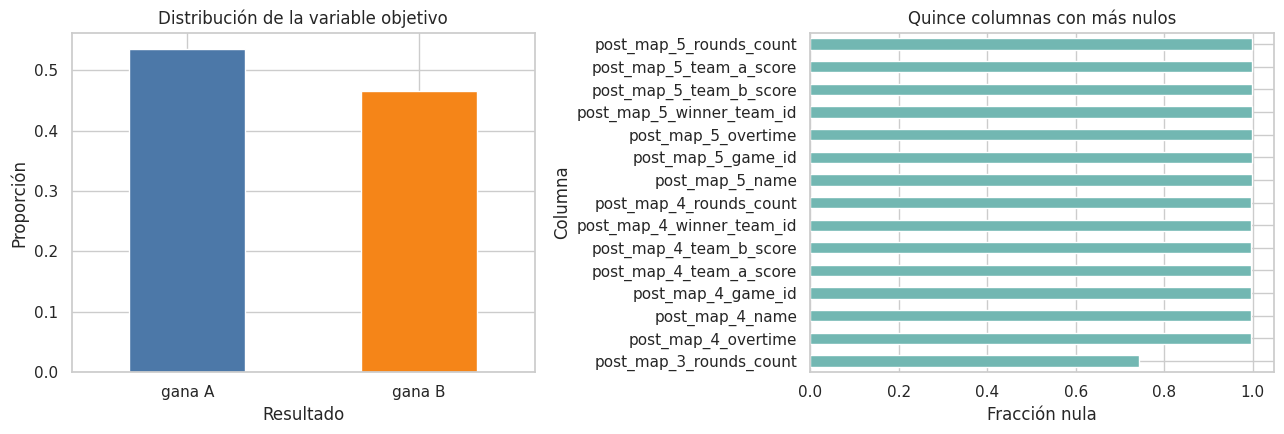

,asimetria
game_version,-11.587648
post_team_a_kast_mean,-1.379643
post_team_b_kast_mean,-1.359500
bo_type,-0.690085
post_map_4_team_a_score,-0.564289
post_map_1_team_a_score,-0.516910
post_map_2_team_a_score,-0.484047
post_map_5_team_b_score,-0.428301
post_map_3_team_a_score,-0.394203
post_map_1_team_b_score,-0.390465


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
objetivo.plot.bar(ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_xlabel("Resultado")
axes[0].set_ylabel("Proporción")
axes[0].tick_params(axis="x", rotation=0)

nulos.head(15).sort_values().plot.barh(ax=axes[1], color="#72B7B2")
axes[1].set_title("Quince columnas con más nulos")
axes[1].set_xlabel("Fracción nula")
axes[1].set_ylabel("Columna")
plt.tight_layout()
plt.show()

asimetria = (df.select_dtypes(include="number").skew(numeric_only=True).sort_values())
display(pd.concat([asimetria.head(10), asimetria.tail(10)]).to_frame("asimetria"))


### 4.1 Interpretación de los nulos

Los nulos de `post_map_3_*`, `post_map_4_*` y `post_map_5_*` pueden ser estructurales: un BO3 que termina 2–0 no tiene tercer mapa y un encuentro que termina antes tampoco tiene cuarto o quinto mapa. Los nulos de estadísticas pueden señalar respuestas parciales de la fuente. Los rankings faltantes reflejan ausencia del dato en Bo3.gg y, aun cuando existen, el valor corresponde al momento de extracción, no necesariamente al momento histórico del partido.


In [ ]:
familias_nulos = pd.DataFrame({
    "familia": ["mapa 3", "mapa 4", "mapa 5", "rank A", "rank B"],
    "columna_ejemplo": [
        "post_map_3_game_id", "post_map_4_game_id", "post_map_5_game_id",
        "team_a_rank_at_extraction", "team_b_rank_at_extraction",
    ],
})
familias_nulos["fraccion_nula"] = familias_nulos["columna_ejemplo"].map(nulos)
display(familias_nulos)
display(df["data_completeness"].value_counts(dropna=False).to_frame("partidos"))
display(df["parsed_status"].value_counts(dropna=False).to_frame("partidos"))


,familia,columna_ejemplo,fraccion_nula
0,mapa 3,post_map_3_game_id,0.712234
1,mapa 4,post_map_4_game_id,0.996088
2,mapa 5,post_map_5_game_id,0.998336
3,rank A,team_a_rank_at_extraction,0.452882
4,rank B,team_b_rank_at_extraction,0.543252


,partidos
data_completeness,
complete,29777
partial,14159
minimal,548


,partidos
parsed_status,
done,25239
rejected,13535
partially_done,5705
waiting,5


## 5. Auditoría de fuga

Una variable es candidata sólo si existiría antes de `start_at_utc`. Los resultados, mapas, rondas y estadísticas del partido actual quedan fuera. Sus valores sí pueden alimentar variables históricas de partidos posteriores, siempre que `end_at_utc` sea estrictamente anterior al inicio del partido que se quiere predecir.


In [ ]:
def clasificar_columna(columna):
    if columna == "target_team_a_won":
        return "objetivo", "Sale", "Es la respuesta a predecir"
    if columna.startswith("post_") or columna in {"winner_team_id", "loser_team_id", "end_at_utc", "duration_seconds"}:
        return "posterior", "Sale", "Fuga: se conoce después del partido"
    if columna in {"team_a_rank_at_extraction", "team_b_rank_at_extraction", "rank_extracted_at_utc"}:
        return "temporal dudosa", "Sale por ahora", "No es un snapshot histórico prepartido"
    if columna.startswith("team_a_lineup") or columna.startswith("team_b_lineup"):
        return "posterior", "Sale", "Fuga: la alineación fue reconstruida desde el partido observado"
    if columna in {"parsed_status", "data_completeness"}:
        return "calidad", "Sale del modelo", "Metadato posterior del procesamiento; se usa sólo para auditar"
    if columna in {"match_id", "match_slug", "team_a_name", "team_b_name", "tournament_name", "stage_name"}:
        return "identificador", "Sale del modelo", "Identifica o etiqueta; se conserva para trazabilidad"
    if columna in constantes:
        return "sin información", "Sale", "Constante o completamente vacía"
    return "prepartido", "Candidata", "Disponible antes del encuentro; requiere codificación si es categórica"

auditoria = pd.DataFrame(
    [(columna, *clasificar_columna(columna)) for columna in df.columns],
    columns=["columna", "momento", "decision", "motivo"],
)
display(auditoria.groupby(["momento", "decision"]).size().rename("columnas").to_frame())
display(auditoria)


,,columnas
momento,decision,
calidad,Sale del modelo,2
identificador,Sale del modelo,6
objetivo,Sale,1
posterior,Sale,98
prepartido,Candidata,10
temporal dudosa,Sale por ahora,3


,columna,momento,decision,motivo
0,match_id,identificador,Sale del modelo,Identifica o etiqueta; se conserva para trazab...
1,match_slug,identificador,Sale del modelo,Identifica o etiqueta; se conserva para trazab...
2,start_at_utc,prepartido,Candidata,Disponible antes del encuentro; requiere codif...
3,end_at_utc,posterior,Sale,Fuga: se conoce después del partido
4,duration_seconds,posterior,Sale,Fuga: se conoce después del partido
5,bo_type,prepartido,Candidata,Disponible antes del encuentro; requiere codif...
6,tier,prepartido,Candidata,Disponible antes del encuentro; requiere codif...
7,game_version,prepartido,Candidata,Disponible antes del encuentro; requiere codif...
8,tournament_id,prepartido,Candidata,Disponible antes del encuentro; requiere codif...
9,tournament_name,identificador,Sale del modelo,Identifica o etiqueta; se conserva para trazab...


## 6. Construcción temporal de variables Gold

`a_kda20`, `b_kda20`, `a_wr10` y `b_wr10` no son columnas originales de Silver. Se calculan para cada equipo usando exclusivamente encuentros cuyo `end_at_utc` es anterior al `start_at_utc` del partido que se quiere predecir. Esto también excluye partidos simultáneos o solapados y evita fuga temporal.

Definimos KDA20 como `(kills + assists) / deaths` acumulado sobre hasta 20 partidos anteriores. WR10 es la media de victorias en hasta 10 partidos anteriores. Exigimos al menos cinco observaciones previas disponibles.


In [ ]:
def construir_lado(data, lado):
    otro = "b" if lado == "a" else "a"
    salida = pd.DataFrame({
        "match_id": data["match_id"],
        "start_at_utc": data["start_at_utc"],
        "end_at_utc": data["end_at_utc"],
        "tier": data["tier"],
        "bo_type": data["bo_type"],
        "lado": lado,
        "team_id": data[f"team_{lado}_id"],
        "opponent_id": data[f"team_{otro}_id"],
        "won": data["target_team_a_won"] if lado == "a" else 1 - data["target_team_a_won"],
        "kills": data[f"post_team_{lado}_kills"],
        "deaths": data[f"post_team_{lado}_deaths"],
        "assists": data[f"post_team_{lado}_assists"],
    })
    return salida

equipo_partido = pd.concat(
    [construir_lado(df, "a"), construir_lado(df, "b")],
    ignore_index=True,
).sort_values(["team_id", "start_at_utc", "match_id"])


def construir_historia_temporal(partidos):
    historias = []
    for _, grupo in partidos.groupby("team_id", sort=False):
        pendientes = []
        completados = []
        grupo = grupo.sort_values(["start_at_utc", "match_id"])
        for fila in grupo.itertuples():
            inicio_ns = fila.start_at_utc.value
            while pendientes and pendientes[0][0] < inicio_ns:
                _, _, anterior = heapq.heappop(pendientes)
                completados.append(anterior)
            ultimos_20 = completados[-20:]
            validos_kda = [r for r in ultimos_20 if pd.notna(r["kills"]) and pd.notna(r["deaths"]) and pd.notna(r["assists"])]
            if len(validos_kda) >= 5:
                muertes = sum(r["deaths"] for r in validos_kda)
                kda20 = (sum(r["kills"] for r in validos_kda) + sum(r["assists"] for r in validos_kda)) / muertes if muertes else np.nan
            else:
                kda20 = np.nan
            ultimos_10 = completados[-10:]
            wr10 = np.mean([r["won"] for r in ultimos_10]) if len(ultimos_10) >= 5 else np.nan
            historias.append({"row_index": fila.Index, "partidos_previos": len(completados), "kda20": kda20, "wr10": wr10})
            if pd.notna(fila.end_at_utc):
                heapq.heappush(pendientes, (fila.end_at_utc.value, int(fila.match_id), {"won": fila.won, "kills": fila.kills, "deaths": fila.deaths, "assists": fila.assists}))
    return pd.DataFrame(historias).set_index("row_index")

equipo_partido = equipo_partido.join(construir_historia_temporal(equipo_partido))

hist_a = (equipo_partido[equipo_partido["lado"] == "a"]
          [["match_id", "kda20", "wr10", "partidos_previos"]]
          .rename(columns={"kda20": "a_kda20", "wr10": "a_wr10", "partidos_previos": "a_partidos_previos"}))
hist_b = (equipo_partido[equipo_partido["lado"] == "b"]
          [["match_id", "kda20", "wr10", "partidos_previos"]]
          .rename(columns={"kda20": "b_kda20", "wr10": "b_wr10", "partidos_previos": "b_partidos_previos"}))
gold = df.merge(hist_a, on="match_id", how="left").merge(hist_b, on="match_id", how="left")
derivadas = pd.DataFrame({
    "kda20_diff": gold["a_kda20"] - gold["b_kda20"],
    "wr10_diff": gold["a_wr10"] - gold["b_wr10"],
    "team_a_win": gold["target_team_a_won"].astype(int),
}, index=gold.index)
gold = pd.concat([gold, derivadas], axis=1).copy()

cobertura_gold = gold[["a_kda20", "b_kda20", "a_wr10", "b_wr10"]].notna().mean()
display(cobertura_gold.rename("cobertura").to_frame())
assert (equipo_partido["partidos_previos"] >= 0).all()
print("Features Gold construidas sólo con partidos ya finalizados.")


,cobertura
a_kda20,0.822026
b_kda20,0.678963
a_wr10,0.826949
b_wr10,0.683324


Features Gold construidas sólo con partidos ya finalizados.


## 7. Medidas y semáforo

Los cortes se aplican sobre el valor absoluto. Rojo indica efecto pequeño, amarillo efecto intermedio que requiere indagación y verde efecto grande según las convenciones de la materia.


In [ ]:
CORTES = {
    "separacion": (0.2, 0.8),
    "eta2": (0.05, 0.25),
    "correlacion": (0.2, 0.6),
    "brecha": (0.05, 0.15),
}

def separacion(x, y):
    x, y = pd.Series(x).dropna(), pd.Series(y).dropna()
    denominador = np.sqrt((x.std() ** 2 + y.std() ** 2) / 2)
    return abs(x.mean() - y.mean()) / denominador if denominador else np.nan

def eta2(numerica, categoria):
    datos = pd.DataFrame({"x": numerica, "g": categoria}).dropna()
    media = datos["x"].mean()
    entre = sum(len(grupo) * (grupo["x"].mean() - media) ** 2 for _, grupo in datos.groupby("g"))
    total = ((datos["x"] - media) ** 2).sum()
    return entre / total if total else np.nan

def asociacion(x, y):
    datos = pd.DataFrame({"x": x, "y": y}).dropna()
    pearson = datos["x"].corr(datos["y"], method="pearson")
    spearman = datos["x"].rank().corr(datos["y"].rank())
    return pd.Series({"pearson": pearson, "spearman": spearman, "brecha_abs": abs(spearman - pearson)})

def semaforo(valor, medida):
    bajo, alto = CORTES[medida]
    valor = abs(valor)
    return "rojo" if valor < bajo else "amarillo" if valor <= alto else "verde"

def tasa_acierto_signo(datos, diferencia, objetivo="team_a_win"):
    validos = datos.loc[datos[diferencia].notna() & datos[diferencia].ne(0)]
    predice_a = validos[diferencia] > 0
    return (predice_a.astype(int) == validos[objetivo].astype(int)).mean(), len(validos)


## 8. Hipótesis 1 · KDA histórico del equipo

1. **La afirmación (predecir):** el equipo con mejor KDA agregado en sus últimos 20 partidos anteriores al encuentro gana más frecuentemente. Variables: `a_kda20`, `b_kda20`, `kda20_diff`; objetivo: `team_a_win`.
2. **Qué esperamos ver:** una proporción de triunfos de A mayor cuando `kda20_diff > 0` y una separación positiva entre los partidos ganados por A y B. Esperamos una señal moderada porque matar más no garantiza ganar la serie.
3. **Cómo la medimos:** separación estandarizada de `kda20_diff` entre ambos resultados, porcentaje de acierto del equipo con mayor KDA20 y tasa de victoria por quintil.
4. **Qué encontramos:** se completa con el número, la zona y el gráfico siguientes.
5. **Qué movimiento hicimos:** si el resultado es amarillo, se controla por tier para comprobar si la mezcla de niveles oculta comportamientos diferentes.
6. **Qué hacemos con eso:** se decide si KDA20 entra, sale o queda pendiente para el modelo.


,resultado
partidos,27827
separacion_d,0.415006
zona,amarillo
acierto_equipo_mejor_kda,0.581845
baseline_mayoritaria,0.516692
mejora_sobre_baseline,0.065153
comparaciones_sin_empate,27827


,mean,size
franja_kda,,
"(-0.893, -0.104]",0.373158,5566
"(-0.104, -0.0313]",0.463792,5565
"(-0.0313, 0.0297]",0.509254,5565
"(0.0297, 0.105]",0.574124,5565
"(0.105, 0.788]",0.663133,5566


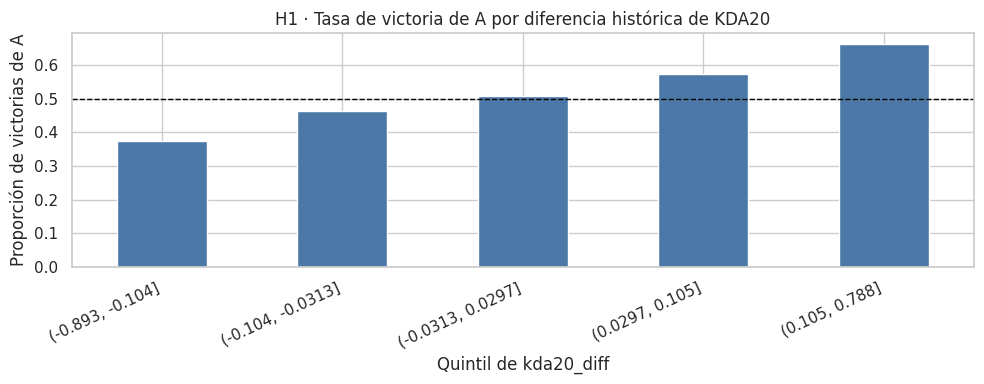

,tier,partidos,separacion_d
0,a,1224,0.192593
1,b,11488,0.465757
2,c,12836,0.409439
3,s,2246,0.275844


Movimiento: controlar por tier. H1 inconclusa. Decisión: kda20_diff queda pendiente tras el movimiento.


In [ ]:
h1 = gold.dropna(subset=["kda20_diff", "team_a_win"]).copy()
assert len(h1) >= 100, "No hay suficientes partidos con historia para evaluar H1."
d_h1 = separacion(h1.loc[h1["team_a_win"] == 1, "kda20_diff"], h1.loc[h1["team_a_win"] == 0, "kda20_diff"])
acierto_h1, n_h1 = tasa_acierto_signo(h1, "kda20_diff")
baseline_h1 = h1["team_a_win"].value_counts(normalize=True).max()
mejora_h1 = acierto_h1 - baseline_h1
zona_h1 = semaforo(d_h1, "separacion")
h1["franja_kda"] = pd.qcut(h1["kda20_diff"], q=5, duplicates="drop")
tasas_h1 = h1.groupby("franja_kda", observed=False)["team_a_win"].agg(["mean", "size"])
display(pd.Series({"partidos": len(h1), "separacion_d": d_h1, "zona": zona_h1, "acierto_equipo_mejor_kda": acierto_h1, "baseline_mayoritaria": baseline_h1, "mejora_sobre_baseline": mejora_h1, "comparaciones_sin_empate": n_h1}).to_frame("resultado"))
display(tasas_h1)
tasas_h1["mean"].plot.bar(figsize=(10, 4), color="#4C78A8")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.title("H1 · Tasa de victoria de A por diferencia histórica de KDA20")
plt.xlabel("Quintil de kda20_diff")
plt.ylabel("Proporción de victorias de A")
plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

movimiento_h1 = "ninguno"
if zona_h1 == "amarillo":
    movimiento_h1 = "controlar por tier"
    control_h1 = []
    for tier, sub in h1.groupby(h1["tier"].astype(str).str.lower()):
        if len(sub) >= 100 and sub["team_a_win"].nunique() == 2:
            control_h1.append((tier, len(sub), separacion(sub.loc[sub.team_a_win == 1, "kda20_diff"], sub.loc[sub.team_a_win == 0, "kda20_diff"])))
    display(pd.DataFrame(control_h1, columns=["tier", "partidos", "separacion_d"]))
veredicto_h1 = "confirmada" if zona_h1 == "verde" else "inconclusa" if zona_h1 == "amarillo" else "refutada"
decision_h1 = "entra como candidata" if zona_h1 == "verde" else "queda pendiente tras el movimiento" if zona_h1 == "amarillo" else "sale por señal débil"
print(f"Movimiento: {movimiento_h1}. H1 {veredicto_h1}. Decisión: kda20_diff {decision_h1}.")


## 9. Hipótesis 2 · Winrate reciente

1. **La afirmación (predecir):** si el winrate de los últimos 10 partidos anteriores de A es mayor que el de B, A gana con más frecuencia. Variables: `a_wr10`, `b_wr10`, `wr10_diff`; objetivo: `team_a_win`.
2. **Qué espero ver:** una proporción de triunfos de A superior al 50 % cuando `wr10_diff > 0`, con señal moderada porque diez partidos no resumen el nivel de los rivales ni los cambios de plantel.
3. **Cómo la mido:** separación estandarizada de `wr10_diff`, porcentaje de acierto del equipo con mayor WR10 y tasa de victoria por franjas. Los empates se informan aparte.
4. **Qué encontré:** se completa con el número, la zona y el gráfico siguientes.
5. **Qué movimiento hice:** si da amarillo, se separa por formato para verificar si BO1 y series largas se comportan distinto.
6. **Qué hago con eso:** se decide si WR10 entra, sale o queda pendiente.


,resultado
partidos,28082
separacion_d,0.335737
zona,amarillo
acierto_equipo_mejor_wr10,0.576213
baseline_mayoritaria,0.516665
mejora_sobre_baseline,0.059548
empates_wr10,4287


,mean,size
franja_wr,,
"(-inf, -0.3]",0.375900,3610
"(-0.3, -0.1]",0.454212,4914
"(-0.1, 0.1]",0.516278,11027
"(0.1, 0.3]",0.586695,5652
"(0.3, inf]",0.663772,2879


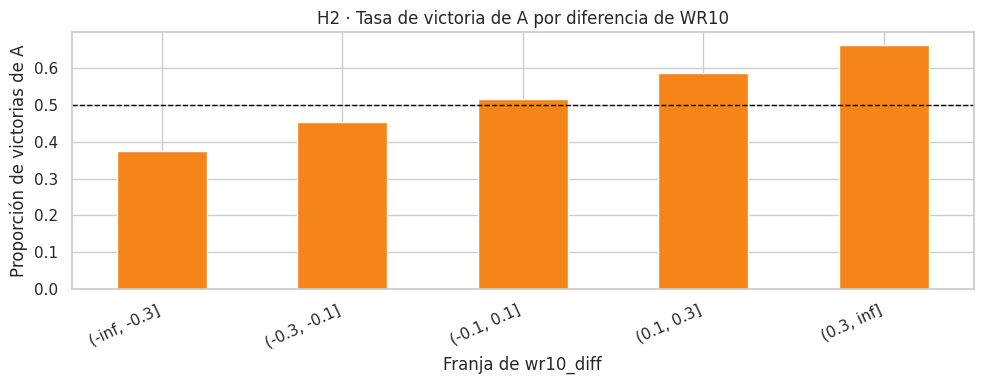

,bo_type,partidos,separacion_d
0,1,6928,0.437582
1,3,20910,0.300571
2,5,233,0.128440


Movimiento: partir por formato. H2 inconclusa. Decisión: wr10_diff queda pendiente tras el movimiento.


In [ ]:
h2 = gold.dropna(subset=["wr10_diff", "team_a_win"]).copy()
assert len(h2) >= 100, "No hay suficientes partidos con historia para evaluar H2."
d_h2 = separacion(h2.loc[h2["team_a_win"] == 1, "wr10_diff"], h2.loc[h2["team_a_win"] == 0, "wr10_diff"])
acierto_h2, n_h2 = tasa_acierto_signo(h2, "wr10_diff")
baseline_h2 = h2["team_a_win"].value_counts(normalize=True).max()
mejora_h2 = acierto_h2 - baseline_h2
zona_h2 = semaforo(d_h2, "separacion")
empates_h2 = int(h2["wr10_diff"].eq(0).sum())
h2["franja_wr"] = pd.cut(h2["wr10_diff"], [-np.inf, -0.30, -0.10, 0.10, 0.30, np.inf], include_lowest=True)
tasas_h2 = h2.groupby("franja_wr", observed=False)["team_a_win"].agg(["mean", "size"])
display(pd.Series({"partidos": len(h2), "separacion_d": d_h2, "zona": zona_h2, "acierto_equipo_mejor_wr10": acierto_h2, "baseline_mayoritaria": baseline_h2, "mejora_sobre_baseline": mejora_h2, "empates_wr10": empates_h2}).to_frame("resultado"))
display(tasas_h2)
tasas_h2["mean"].plot.bar(figsize=(10, 4), color="#F58518")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.title("H2 · Tasa de victoria de A por diferencia de WR10")
plt.xlabel("Franja de wr10_diff")
plt.ylabel("Proporción de victorias de A")
plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

movimiento_h2 = "ninguno"
if zona_h2 == "amarillo":
    movimiento_h2 = "partir por formato"
    control_h2 = []
    for formato, sub in h2.groupby("bo_type"):
        if len(sub) >= 100 and sub["team_a_win"].nunique() == 2:
            control_h2.append((formato, len(sub), separacion(sub.loc[sub.team_a_win == 1, "wr10_diff"], sub.loc[sub.team_a_win == 0, "wr10_diff"])))
    display(pd.DataFrame(control_h2, columns=["bo_type", "partidos", "separacion_d"]))
veredicto_h2 = "confirmada" if zona_h2 == "verde" else "inconclusa" if zona_h2 == "amarillo" else "refutada"
decision_h2 = "entra como candidata" if zona_h2 == "verde" else "queda pendiente tras el movimiento" if zona_h2 == "amarillo" else "sale por señal débil"
print(f"Movimiento: {movimiento_h2}. H2 {veredicto_h2}. Decisión: wr10_diff {decision_h2}.")


## 10. Hipótesis 3 · Dominancia de BO3 en Tier S

1. **La afirmación (responder):** entre los partidos Tier S, los mejores de tres representan más del 90 %.
2. **Qué espero ver:** una barra BO3 claramente dominante y una proporción superior a 0,90. Si BO1 o BO5 tienen un peso considerable, la afirmación será falsa.
3. **Cómo la mido:** composición `n(Tier S y BO3) / n(Tier S)`, comparada con el umbral 90 % fijado antes de observar los datos. No se aplican a esta proporción los cortes universales de correlación.
4. **Qué encontré:** se informa debajo la proporción exacta y el gráfico.
5. **Qué movimiento hice:** ninguno; el umbral forma parte de la afirmación original.
6. **Qué hago con eso:** describe el dominio y ayuda a decidir si el formato debe conservarse como variable o si casi no aporta variación dentro de Tier S.


,resultado
partidos_tier_s,2363
proporcion_bo3,0.828608
umbral,0.9
veredicto,refutada


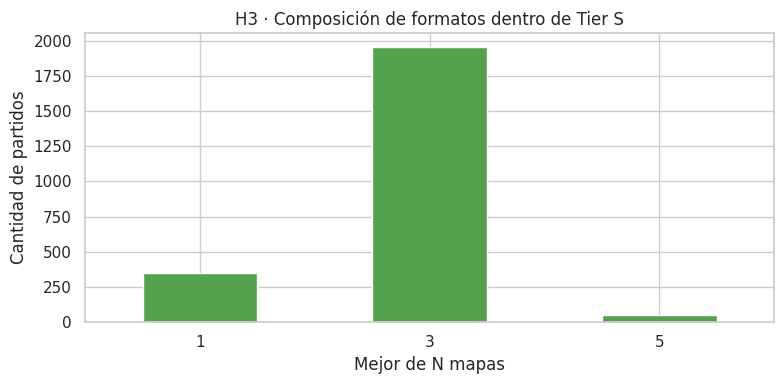

H3 queda refutada: BO3 representa 82.9% de Tier S.


In [ ]:
tier_normalizado = df["tier"].astype(str).str.lower().str.strip()
bo_numero = pd.to_numeric(df["bo_type"].astype(str).str.extract(r"(\d+)", expand=False), errors="coerce")
h3 = pd.DataFrame({"tier": tier_normalizado, "bo": bo_numero}).query("tier == 's'")
assert len(h3) > 0, "No hay partidos Tier S para evaluar H3."
composicion_h3 = h3["bo"].value_counts(dropna=False).sort_index()
proporcion_bo3 = h3["bo"].eq(3).mean()
veredicto_h3 = "confirmada" if proporcion_bo3 > 0.90 else "refutada"
display(pd.Series({"partidos_tier_s": len(h3), "proporcion_bo3": proporcion_bo3, "umbral": 0.90, "veredicto": veredicto_h3}).to_frame("resultado"))
composicion_h3.plot.bar(figsize=(8, 4), color="#54A24B")
plt.title("H3 · Composición de formatos dentro de Tier S")
plt.xlabel("Mejor de N mapas")
plt.ylabel("Cantidad de partidos")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
print(f"H3 queda {veredicto_h3}: BO3 representa {proporcion_bo3:.1%} de Tier S.")

## 11. Hipótesis 4 · KDA20 y WR10 aportan señales distintas

1. **La afirmación (predecir):** `kda20_diff` y `wr10_diff` no son redundantes y no presentan una asociación fuerte.
2. **Qué espero ver:** una nube ascendente pero dispersa y una correlación absoluta menor que 0,60. El rendimiento mecánico debería relacionarse con ganar, sin resumir exactamente lo mismo.
3. **Cómo la mido:** Pearson, Spearman y su brecha; gráfico de dispersión. Correlación roja confirma claramente señales distintas, amarilla deja la decisión inconclusa y verde refuta la afirmación de no redundancia.
4. **Qué encontré:** se completa con los tres números y el gráfico.
5. **Qué movimiento hice:** ante zona amarilla se controla por tier para buscar poblaciones con comportamientos diferentes.
6. **Qué hago con eso:** conservar ambas, revisar por tier o elegir/regularizar una de las dos.


,resultado
pearson,0.648918
spearman,0.626803
brecha_abs,0.022114
zona_correlacion,verde
zona_brecha,rojo
veredicto,refutada


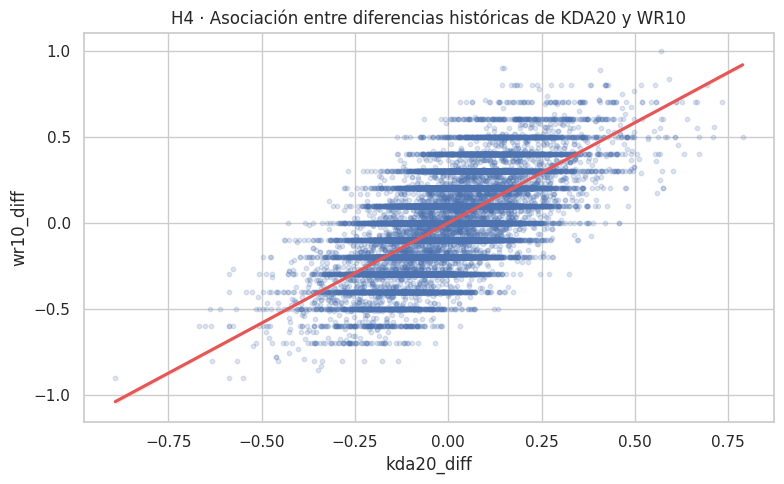

Movimiento: ninguno. H4 refutada; decisión: revisar redundancia antes de incluir ambas.


In [ ]:
h4 = gold.dropna(subset=["kda20_diff", "wr10_diff"]).copy()
assert len(h4) >= 100, "No hay suficientes partidos con ambas features para evaluar H4."
asoc_h4 = asociacion(h4["kda20_diff"], h4["wr10_diff"])
zona_h4 = semaforo(asoc_h4["spearman"], "correlacion")
zona_brecha_h4 = semaforo(asoc_h4["brecha_abs"], "brecha")
veredicto_h4 = "confirmada" if zona_h4 == "rojo" else "inconclusa" if zona_h4 == "amarillo" else "refutada"
display(pd.concat([asoc_h4, pd.Series({"zona_correlacion": zona_h4, "zona_brecha": zona_brecha_h4, "veredicto": veredicto_h4})]).to_frame("resultado"))
plt.figure(figsize=(8, 5))
sns.regplot(data=h4, x="kda20_diff", y="wr10_diff", scatter_kws={"s": 10, "alpha": 0.18}, line_kws={"color": "#E45756"})
plt.title("H4 · Asociación entre diferencias históricas de KDA20 y WR10")
plt.xlabel("kda20_diff")
plt.ylabel("wr10_diff")
plt.tight_layout(); plt.show()

movimiento_h4 = "ninguno"
if zona_h4 == "amarillo":
    movimiento_h4 = "controlar por tier"
    control_h4 = []
    for tier, sub in h4.groupby(h4["tier"].astype(str).str.lower()):
        if len(sub) >= 100:
            control_h4.append((tier, len(sub), sub["kda20_diff"].rank().corr(sub["wr10_diff"].rank())))
    display(pd.DataFrame(control_h4, columns=["tier", "partidos", "spearman"]))
decision_h4 = "conservar ambas" if zona_h4 == "rojo" else "evaluar regularización o selección" if zona_h4 == "amarillo" else "revisar redundancia antes de incluir ambas"
print(f"Movimiento: {movimiento_h4}. H4 {veredicto_h4}; decisión: {decision_h4}.")


## 12. Tabla de columnas candidatas para la Entrega 3

La tabla separa variables utilizables, identificadores, fugas y variables que todavía requieren una fuente histórica correcta. La decisión final de KDA20 y WR10 se actualiza con los resultados anteriores.


In [ ]:
candidatas = pd.DataFrame([
    ("bo_type", "Formato planificado del partido", "sin semáforo", "Entra codificada", "Sí"),
    ("tier", "Nivel competitivo del torneo", "sin semáforo", "Entra codificada", "Sí"),
    ("game_version", "Versión del juego", "sin semáforo", "Evaluar cardinalidad", "Sí"),
    ("tournament_id", "Torneo", "sin semáforo", "Evaluar codificación y generalización", "Sí"),
    ("stage_id", "Etapa del torneo", "sin semáforo", "Evaluar codificación", "Sí"),
    ("team_a_id / team_b_id", "Identidad de los equipos", "sin semáforo", "No entran como números; sirven para generar historia", "Sí"),
    ("a_kda20 / b_kda20 / kda20_diff", "Calidad mecánica histórica", zona_h1, decision_h1, "Sí: sólo usa partidos finalizados antes del inicio"),
    ("a_wr10 / b_wr10 / wr10_diff", "Forma histórica reciente", zona_h2, decision_h2, "Sí: sólo usa partidos finalizados antes del inicio"),
    ("team_*_rank_at_extraction", "Ranking observado al extraer", "no evaluada", "Sale hasta tener snapshots históricos", "No garantizado"),
    ("winner_team_id / loser_team_id", "Resultado del partido", "fuga", "Sale", "No"),
    ("post_*", "Resultado, mapas, rondas y estadísticas actuales", "fuga", "Salen del modelo actual; alimentan historia futura", "No"),
    ("target_team_a_won", "Objetivo", "objetivo", "Es la que se busca predecir", "No"),
], columns=["Columna", "Qué mide", "Zona", "Decisión", "¿Existiría al predecir?"])
display(candidatas)


,Columna,Qué mide,Zona,Decisión,¿Existiría al predecir?
0,bo_type,Formato planificado del partido,sin semáforo,Entra codificada,Sí
1,tier,Nivel competitivo del torneo,sin semáforo,Entra codificada,Sí
2,game_version,Versión del juego,sin semáforo,Evaluar cardinalidad,Sí
3,tournament_id,Torneo,sin semáforo,Evaluar codificación y generalización,Sí
4,stage_id,Etapa del torneo,sin semáforo,Evaluar codificación,Sí
5,team_a_id / team_b_id,Identidad de los equipos,sin semáforo,No entran como números; sirven para generar hi...,Sí
6,a_kda20 / b_kda20 / kda20_diff,Calidad mecánica histórica,amarillo,queda pendiente tras el movimiento,Sí: sólo usa partidos finalizados antes del in...
7,a_wr10 / b_wr10 / wr10_diff,Forma histórica reciente,amarillo,queda pendiente tras el movimiento,Sí: sólo usa partidos finalizados antes del in...
8,team_*_rank_at_extraction,Ranking observado al extraer,no evaluada,Sale hasta tener snapshots históricos,No garantizado
9,winner_team_id / loser_team_id,Resultado del partido,fuga,Sale,No


## 13. Conclusiones y pendientes

Las conclusiones definitivas deben redactarse después de ejecutar todo el notebook. Deben incluir: distribución del objetivo; cobertura real de las variables Gold; resultado y decisión de cada hipótesis; variables descartadas por fuga; y limitaciones.

El principal pendiente conceptual es disponer de snapshots históricos de ranking y alineaciones anteriores a cada partido. Hasta entonces, los rankings observados durante la extracción no deben presentarse como variables prepartido históricas.


In [ ]:
veredictos = pd.DataFrame([
    ("H1 · KDA20", zona_h1, f"{veredicto_h1}; {decision_h1}"),
    ("H2 · WR10", zona_h2, f"{veredicto_h2}; {decision_h2}"),
    ("H3 · BO3 en Tier S", "verde" if veredicto_h3 == "confirmada" else "rojo", veredicto_h3),
    ("H4 · Redundancia", zona_h4, f"{veredicto_h4}; {decision_h4}"),
], columns=["hipotesis", "zona", "decision"])
resumen_exposicion = pd.Series({
    "filas": len(df),
    "columnas": df.shape[1],
    "clave": "match_id",
    "duplicados_clave": int(df["match_id"].duplicated().sum()),
    "objetivo": "target_team_a_won",
    "proporcion_gana_a": df["target_team_a_won"].mean(),
    "columnas_constantes": len(constantes),
    "cobertura_kda20_ambos": gold[["a_kda20", "b_kda20"]].notna().all(axis=1).mean(),
    "cobertura_wr10_ambos": gold[["a_wr10", "b_wr10"]].notna().all(axis=1).mean(),
})
display(resumen_exposicion.to_frame("valor"))
display(veredictos)
display(nulos.head(3).rename("fraccion_nula").to_frame())


,valor
filas,44484
columnas,120
clave,match_id
duplicados_clave,0
objetivo,target_team_a_won
proporcion_gana_a,0.535136
columnas_constantes,0
cobertura_kda20_ambos,0.625551
cobertura_wr10_ambos,0.631283


,hipotesis,zona,decision
0,H1 · KDA20,amarillo,inconclusa; queda pendiente tras el movimiento
1,H2 · WR10,amarillo,inconclusa; queda pendiente tras el movimiento
2,H3 · BO3 en Tier S,rojo,refutada
3,H4 · Redundancia,verde,refutada; revisar redundancia antes de incluir...


,fraccion_nula
post_map_5_rounds_count,0.998561
post_map_5_team_a_score,0.998471
post_map_5_winner_team_id,0.998471
